<a href="https://colab.research.google.com/github/VidushiBhatia/U-Net-Implementation/blob/main/U_Net_for_Image_Segmentation_From_Scratch_Using_TensorFlow_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Segmentation with U-Net

This notebook consists of an implementation of U-Net using the following resources:
* **Algorithm**: Ronneberger et al., [U-Net](https://arxiv.org/abs/1505.04597) Convolutional Networks for Biomedical Image Segmentation
* **Dataset**: [oxford iiit pet dataset](https://www.kaggle.com/tanlikesmath/the-oxfordiiit-pet-dataset) (published by Kaggle)
* **Packages Used**: TensorFlow, NumPy, scikit-learn, python-Pillow, imageio, matplotlib

In [1]:
!wget -q http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget -q http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xzf images.tar.gz && tar -xzf annotations.tar.gz


# Code Breakdown

- [1 - Packages](#1)
- [2 - Helper Functions for Data Processing](#2)
    - [2.1 - Load Data](#2.1)
    - [2.2 - Pre-Process Data](#2.2)
- [3 - Helper Functions for U-Net Architecture](#3)
    - [3.1 - U-Net Encoder Block](#3.1)
    - [3.2 - U-Net Decoder Block](#3.2)
    - [3.3 - Compile U-Net Blocks](#3.3)
- [4 - Executing above Functions to Train the Model](#4)
    - [4.1 - Load and View Data](#4.1)
    - [4.2 - Process Data](#4.2)
    - [4.3 - Split Train and Test](#4.3)
    - [4.4 - Build U-Net Architecture](#4.4)
    - [4.5 - Compile and Run Model](#4.5)
- [5 - Evaluate Results](#5)
    - [5.1 - Bias-Variance Check](#5.1)
    - [5.2 - View Predicted Segmentations](#5.2)

<a name='1'></a>
# 1 - Packages

In [2]:
# for data load
import os

# for reading and processing images
import imageio
from PIL import Image

# for visualizations
import matplotlib.pyplot as plt

import numpy as np # for using np arrays

# for bulding and running deep learning model
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.losses import binary_crossentropy
from sklearn.model_selection import train_test_split

<a name='2'></a>
# 2 - Helper Functions for Data Processing

<a name='2.1'></a>
## 2.1 - Load Data
* the masked images are stored as png, unmasked (original) as jpg
* the names of these 2 are same so for getting the right sample we can just sort the 2 lists

In [3]:
def LoadData(path1, path2):
    # only real .jpg images
    imgs = sorted([f for f in os.listdir(path1)
                   if f.lower().endswith('.jpg')])
    # only real .png masks, skip macOS “._” files
    masks = sorted([f for f in os.listdir(path2)
                    if f.lower().endswith('.png')
                    and not f.startswith('._')])
    return imgs, masks

<a name='2.2'></a>
## 2.2 - Pre-Process Data

In [4]:
def PreprocessData(img, mask, target_shape_img, target_shape_mask, path1, path2):
    """
    Processes the images and mask present in the shared list and path
    Returns a NumPy dataset with images as 3-D arrays of desired size
    Please note the masks in this dataset have only one channel
    """
    # Pull the relevant dimensions for image and mask
    m = len(img)                     # number of images
    i_h,i_w,i_c = target_shape_img   # pull height, width, and channels of image
    m_h,m_w,m_c = target_shape_mask  # pull height, width, and channels of mask

    # Define X and Y as number of images along with shape of one image
    X = np.zeros((m,i_h,i_w,i_c), dtype=np.float32)
    y = np.zeros((m,m_h,m_w,m_c), dtype=np.int32)

    # Resize images and masks
    for file in img:
        # convert image into an array of desired shape (3 channels)
        index = img.index(file)
        path = os.path.join(path1, file)
        single_img = Image.open(path).convert('RGB')
        single_img = single_img.resize((i_h,i_w))
        single_img = np.reshape(single_img,(i_h,i_w,i_c))
        single_img = single_img/256.
        X[index] = single_img

        # convert mask into an array of desired shape (1 channel)
        single_mask_ind = mask[index]
        path = os.path.join(path2, single_mask_ind)
        single_mask = Image.open(path)
        single_mask = single_mask.resize((m_h, m_w))
        single_mask = np.reshape(single_mask,(m_h,m_w,m_c))
        single_mask = single_mask - 1 # to ensure classes #s start from 0
        y[index] = single_mask
    return X, y

<a name='3'></a>
#3 - Constructing the U-Net Architecture


<a name='3.1'></a>
## 3.1 - U-Net Encoder Block

In [5]:
def EncoderMiniBlock(inputs, n_filters=32, dropout_prob=0.3, max_pooling=True):
    """
    This block uses multiple convolution layers, max pool, relu activation to create an architecture for learning.
    Dropout can be added for regularization to prevent overfitting.
    The block returns the activation values for next layer along with a skip connection which will be used in the decoder
    """
    # Add 2 Conv Layers with relu activation and HeNormal initialization using TensorFlow
    # Proper initialization prevents from the problem of exploding and vanishing gradients
    # 'Same' padding will pad the input to conv layer such that the output has the same height and width (hence, is not reduced in size)
    conv = Conv2D(n_filters,
                  3,   # Kernel size
                  activation='relu',
                  padding='same',
                  kernel_initializer='HeNormal')(inputs)
    conv = Conv2D(n_filters,
                  3,   # Kernel size
                  activation='relu',
                  padding='same',
                  kernel_initializer='HeNormal')(conv)

    # Batch Normalization will normalize the output of the last layer based on the batch's mean and standard deviation
    conv = BatchNormalization()(conv, training=False)

    # In case of overfitting, dropout will regularize the loss and gradient computation to shrink the influence of weights on output
    if dropout_prob > 0:
        conv = tf.keras.layers.Dropout(dropout_prob)(conv)

    # Pooling reduces the size of the image while keeping the number of channels same
    # Pooling has been kept as optional as the last encoder layer does not use pooling (hence, makes the encoder block flexible to use)
    # Below, Max pooling considers the maximum of the input slice for output computation and uses stride of 2 to traverse across input image
    if max_pooling:
        next_layer = tf.keras.layers.MaxPooling2D(pool_size = (2,2))(conv)
    else:
        next_layer = conv

    # skip connection (without max pooling) will be input to the decoder layer to prevent information loss during transpose convolutions
    skip_connection = conv

    return next_layer, skip_connection

<a name='3.2'></a>
## 3.2 - U-Net Decoder Block

In [6]:
def DecoderMiniBlock(prev_layer_input, skip_layer_input, n_filters=32):
    """
    Decoder Block first uses transpose convolution to upscale the image to a bigger size and then,
    merges the result with skip layer results from encoder block
    Adding 2 convolutions with 'same' padding helps further increase the depth of the network for better predictions
    The function returns the decoded layer output
    """
    # Start with a transpose convolution layer to first increase the size of the image
    up = Conv2DTranspose(
                 n_filters,
                 (3,3),    # Kernel size
                 strides=(2,2),
                 padding='same')(prev_layer_input)

    # Merge the skip connection from previous block to prevent information loss
    merge = concatenate([up, skip_layer_input], axis=3)

    # Add 2 Conv Layers with relu activation and HeNormal initialization for further processing
    # The parameters for the function are similar to encoder
    conv = Conv2D(n_filters,
                 3,     # Kernel size
                 activation='relu',
                 padding='same',
                 kernel_initializer='HeNormal')(merge)
    conv = Conv2D(n_filters,
                 3,   # Kernel size
                 activation='relu',
                 padding='same',
                 kernel_initializer='HeNormal')(conv)
    return conv

<a name='3.3'></a>
## 3.3 - Compile U-Net Blocks

In [7]:
def UNetCompiled(input_size=(128, 128, 3), n_filters=32, n_classes=3):
    """
    Combine both encoder and decoder blocks according to the U-Net research paper
    Return the model as output
    """
    # Input size represent the size of 1 image (the size used for pre-processing)
    inputs = Input(input_size)

    # Encoder includes multiple convolutional mini blocks with different maxpooling, dropout and filter parameters
    # Observe that the filters are increasing as we go deeper into the network which will increasse the # channels of the image
    cblock1 = EncoderMiniBlock(inputs, n_filters,dropout_prob=0, max_pooling=True)
    cblock2 = EncoderMiniBlock(cblock1[0],n_filters*2,dropout_prob=0, max_pooling=True)
    cblock3 = EncoderMiniBlock(cblock2[0], n_filters*4,dropout_prob=0, max_pooling=True)
    cblock4 = EncoderMiniBlock(cblock3[0], n_filters*8,dropout_prob=0.3, max_pooling=True)
    cblock5 = EncoderMiniBlock(cblock4[0], n_filters*16, dropout_prob=0.3, max_pooling=False)

    # Decoder includes multiple mini blocks with decreasing number of filters
    # Observe the skip connections from the encoder are given as input to the decoder
    # Recall the 2nd output of encoder block was skip connection, hence cblockn[1] is used
    ublock6 = DecoderMiniBlock(cblock5[0], cblock4[1],  n_filters * 8)
    ublock7 = DecoderMiniBlock(ublock6, cblock3[1],  n_filters * 4)
    ublock8 = DecoderMiniBlock(ublock7, cblock2[1],  n_filters * 2)
    ublock9 = DecoderMiniBlock(ublock8, cblock1[1],  n_filters)

    # Complete the model with 1 3x3 convolution layer (Same as the prev Conv Layers)
    # Followed by a 1x1 Conv layer to get the image to the desired size.
    # Observe the number of channels will be equal to number of output classes
    conv9 = Conv2D(n_filters,
                 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer='he_normal')(ublock9)

    conv10 = Conv2D(n_classes, 1, padding='same')(conv9)

    # Define the model
    model = tf.keras.Model(inputs=inputs, outputs=conv10)

    return model

<a name='4'></a>
# 4 - Executing above Functions to Train the Model

<a name='4.1'></a>
## 4.1 - Load and View Data

/tmp/ipykernel_932/3088519389.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_view  = imageio.imread(path1 + img[i])
/tmp/ipykernel_932/3088519389.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_view = imageio.imread(path2 + mask[i])


(400, 600, 3)
(400, 600)


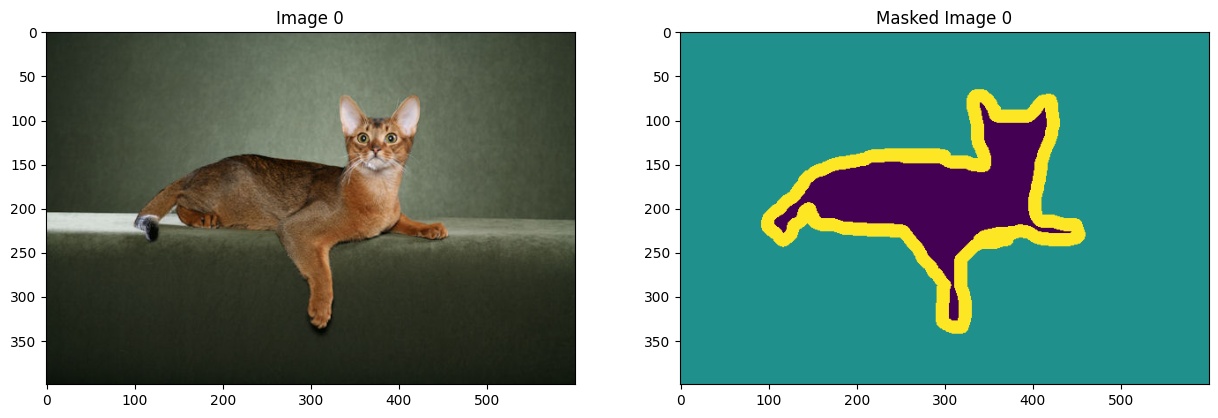

In [8]:
""" Load Train Set and view some examples """
# Call the apt function
path1 = 'images/'
path2 = 'annotations/trimaps/'
img, mask = LoadData (path1, path2)

# View an example of image and corresponding mask
show_images = 1
for i in range(show_images):
    img_view  = imageio.imread(path1 + img[i])
    mask_view = imageio.imread(path2 + mask[i])
    print(img_view.shape)
    print(mask_view.shape)
    fig, arr = plt.subplots(1, 2, figsize=(15, 15))
    arr[0].imshow(img_view)
    arr[0].set_title('Image '+ str(i))
    arr[1].imshow(mask_view)
    arr[1].set_title('Masked Image '+ str(i))

<a name='4.2'></a>
## 4.2 - Process Data

X Shape: (7390, 128, 128, 3)
Y shape: (7390, 128, 128, 1)
[0 1 2]


Text(0.5, 1.0, 'Processed Masked Image ')

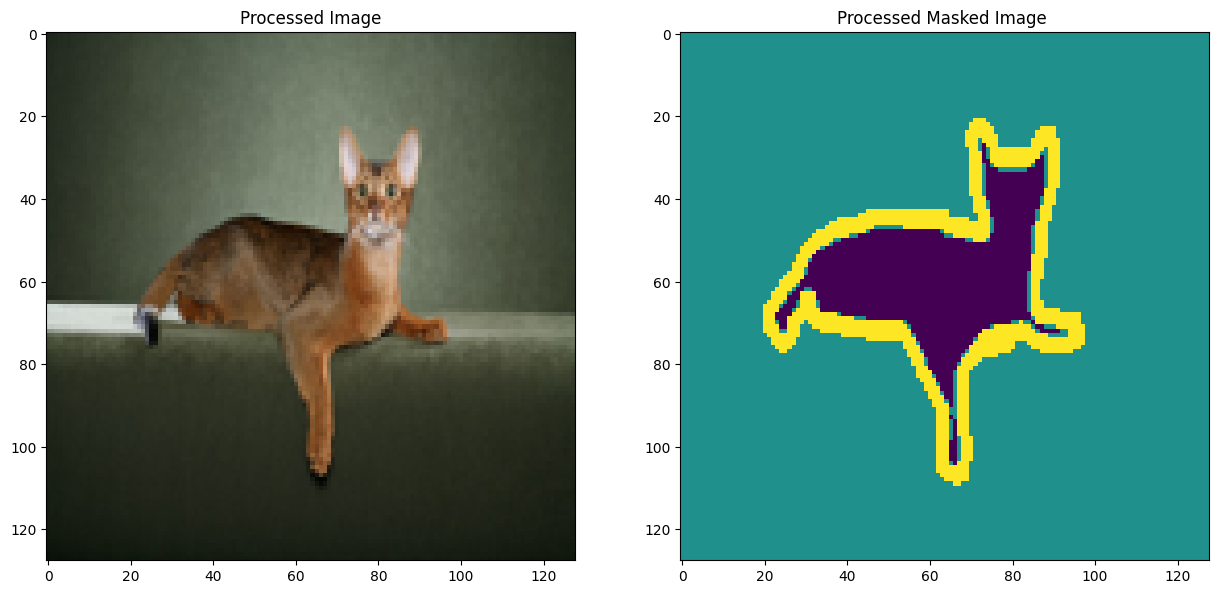

In [9]:
# Define the desired shape
target_shape_img = [128, 128, 3]
target_shape_mask = [128, 128, 1]

# Process data using apt helper function
X, y = PreprocessData(img, mask, target_shape_img, target_shape_mask, path1, path2)

# QC the shape of output and classes in output dataset
print("X Shape:", X.shape)
print("Y shape:", y.shape)
# There are 3 classes : background, pet, outline
print(np.unique(y))

# Visualize the output
image_index = 0
fig, arr = plt.subplots(1, 2, figsize=(15, 15))
arr[0].imshow(X[image_index])
arr[0].set_title('Processed Image')
arr[1].imshow(y[image_index,:,:,0])
arr[1].set_title('Processed Masked Image ')

## 4.3 - Split Train and Test Set

In [10]:
# Use scikit-learn's function to split the dataset
# Here, I have used 20% data as test/valid set
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=123)

<a name='4.4'></a>
## 4.4 - Build U-Net Architecture

In [11]:
# Call the helper function for defining the layers for the model, given the input image size
unet = UNetCompiled(input_size=(128,128,3), n_filters=32, n_classes=3)

In [12]:
# Check the summary to better interpret how the output dimensions change in each layer
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ batch_normalizat

 Total params: 8,643,779 (32.97 MB)

 Trainable params: 8,641,795 (32.97 MB)

 Non-trainable params: 1,984 (7.75 KB)

<a name='4.5'></a>
## 4.5 - Compile and Run Model

In [13]:
# There are multiple optimizers, loss functions and metrics that can be used to compile multi-class segmentation models
# Ideally, try different options to get the best accuracy
unet.compile(optimizer=tf.keras.optimizers.Adam(),
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [14]:
# Run the model in a mini-batch fashion and compute the progress for each epoch
results = unet.fit(X_train, y_train, batch_size=32, epochs=5, validation_data=(X_valid, y_valid))

Epoch 1/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 108s 367ms/step - accuracy: 0.7507 - loss: 0.6088 - val_accuracy: 0.7619 - val_loss: 0.6803
Epoch 2/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 36s 197ms/step - accuracy: 0.8308 - loss: 0.4443 - val_accuracy: 0.7859 - val_loss: 0.6292
Epoch 3/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 36s 195ms/step - accuracy: 0.8518 - loss: 0.3876 - val_accuracy: 0.8233 - val_loss: 0.4467
Epoch 4/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 36s 195ms/step - accuracy: 0.8623 - loss: 0.3626 - val_accuracy: 0.8315 - val_loss: 0.4900
Epoch 5/5
185/185 ━━━━━━━━━━━━━━━━━━━━ 36s 196ms/step - accuracy: 0.8749 - loss: 0.3308 - val_accuracy: 0.8603 - val_loss: 0.3783


<a name='5'></a>
# 5 - Evaluate Model Results

<a name='5.1'></a>
## 5.1 - Bias Variance Check

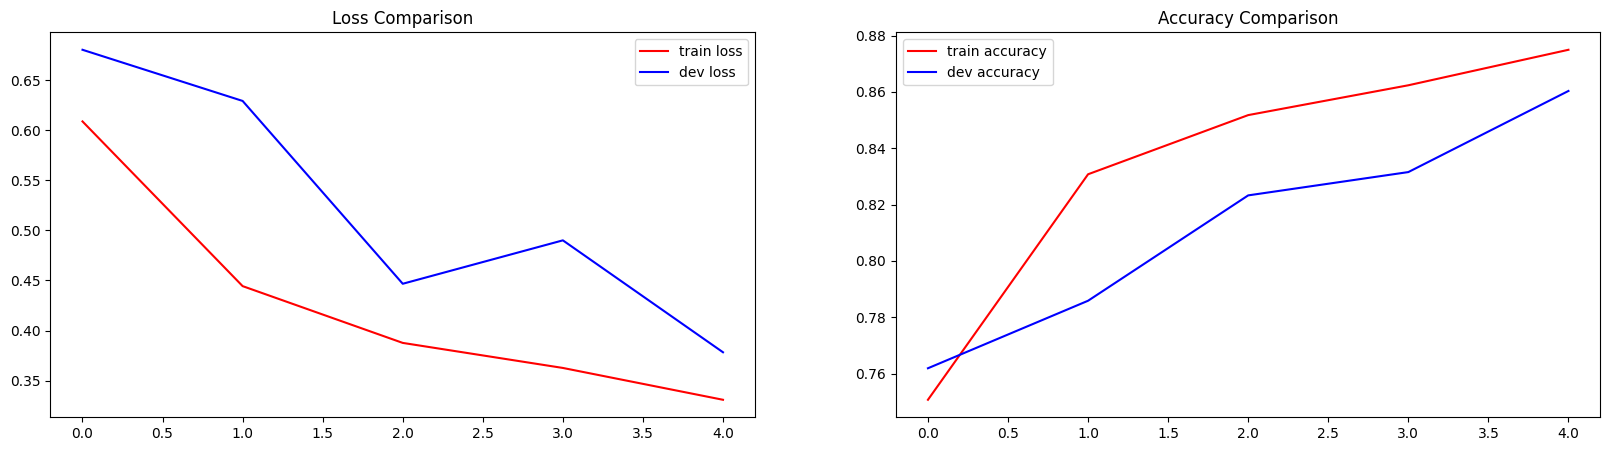

In [15]:
# High Bias is a characteristic of an underfitted model and we would observe low accuracies for both train and validation set
# High Variance is a characterisitic of an overfitted model and we would observe high accuracy for train set and low for validation set
# To check for bias and variance plit the graphs for accuracy
# I have plotted for loss too, this helps in confirming if the loss is decreasing with each iteration - hence, the model is optimizing fine
fig, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].plot(results.history["loss"], color='r', label = 'train loss')
axis[0].plot(results.history["val_loss"], color='b', label = 'dev loss')
axis[0].set_title('Loss Comparison')
axis[0].legend()
axis[1].plot(results.history["accuracy"], color='r', label = 'train accuracy')
axis[1].plot(results.history["val_accuracy"], color='b', label = 'dev accuracy')
axis[1].set_title('Accuracy Comparison')
axis[1].legend()

# RESULTS
# The train loss is consistently decreasing showing that Adam is able to optimize the model and find the minima
# The accuracy of train and validation is ~90% which is high enough, so low bias
# and the %s aren't that far apart, hence low variance

<a name='5.2'></a>
## 5.2 - View Predicted Segmentations

In [16]:
unet.evaluate(X_valid, y_valid)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8603 - loss: 0.3783


[0.3782862722873688, 0.8603295683860779]

In [17]:
# Results of Validation Dataset
def VisualizeResults(index):
    img = X_valid[index]
    img = img[np.newaxis, ...]
    pred_y = unet.predict(img)
    pred_mask = tf.argmax(pred_y[0], axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    fig, arr = plt.subplots(1, 3, figsize=(15, 15))
    arr[0].imshow(X_valid[index])
    arr[0].set_title('Processed Image')
    arr[1].imshow(y_valid[index,:,:,0])
    arr[1].set_title('Actual Masked Image ')
    arr[2].imshow(pred_mask[:,:,0])
    arr[2].set_title('Predicted Masked Image ')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


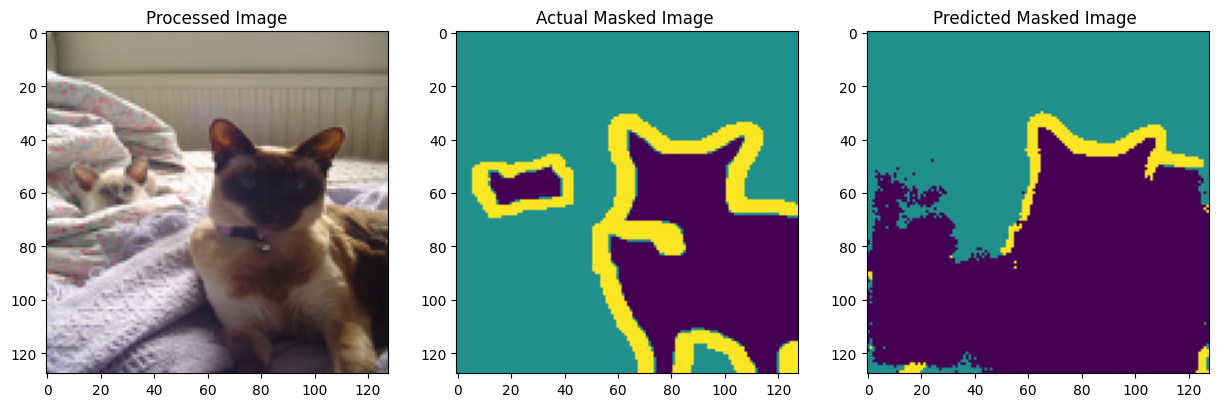

In [18]:
# Add any index to contrast the predicted mask with actual mask
index = 700
VisualizeResults(index)

# Fun Activity

1. Improve model accuracy by changing hyperparameters of the model.
2. Save the model weights.
3. Load the model, use any random pet image and remove the background using the segment.


In [19]:
# Improved U-Net model using tuned hyperparameters

unet = UNetCompiled(
    input_size=(128, 128, 3),
    n_filters=32,
    n_classes=3
)

unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

results = unet.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=10,
    validation_data=(X_valid, y_valid)
)

Epoch 1/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 106s 178ms/step - accuracy: 0.7242 - loss: 0.6467 - val_accuracy: 0.7810 - val_loss: 0.5623
Epoch 2/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - accuracy: 0.8166 - loss: 0.4670 - val_accuracy: 0.8145 - val_loss: 0.4781
Epoch 3/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 39s 107ms/step - accuracy: 0.8376 - loss: 0.4165 - val_accuracy: 0.8400 - val_loss: 0.4138
Epoch 4/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - accuracy: 0.8529 - loss: 0.3793 - val_accuracy: 0.8390 - val_loss: 0.4213
Epoch 5/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - accuracy: 0.8632 - loss: 0.3537 - val_accuracy: 0.8414 - val_loss: 0.4086
Epoch 6/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 39s 107ms/step - accuracy: 0.8731 - loss: 0.3290 - val_accuracy: 0.8451 - val_loss: 0.4165
Epoch 7/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - accuracy: 0.8799 - loss: 0.3108 - val_accuracy: 0.8462 - val_loss: 0.4251
Epoch 8/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 39s 107ms/step - accuracy: 0.8880 - loss: 

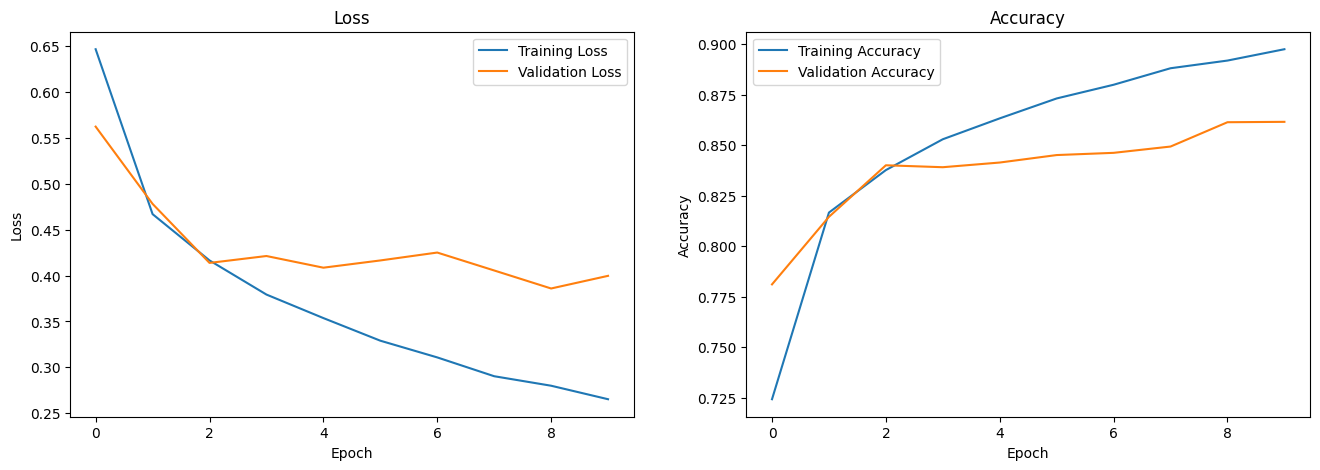

In [20]:
# Plot training and validation performance

fig, axis = plt.subplots(1, 2, figsize=(16, 5))

axis[0].plot(results.history["loss"], label="Training Loss")
axis[0].plot(results.history["val_loss"], label="Validation Loss")
axis[0].set_title("Loss")
axis[0].set_xlabel("Epoch")
axis[0].set_ylabel("Loss")
axis[0].legend()

axis[1].plot(results.history["accuracy"], label="Training Accuracy")
axis[1].plot(results.history["val_accuracy"], label="Validation Accuracy")
axis[1].set_title("Accuracy")
axis[1].set_xlabel("Epoch")
axis[1].set_ylabel("Accuracy")
axis[1].legend()

plt.show()

In [21]:
# Evaluate the improved model

loss, accuracy = unet.evaluate(X_valid, y_valid)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8615 - loss: 0.3997
Validation Loss: 0.3997039496898651
Validation Accuracy: 0.8614997267723083


In [22]:
# Save the trained model weights

unet.save_weights("unet_pet_segmentation.weights.h5")

print("Model weights saved successfully.")

Model weights saved successfully.


In [23]:
# Create a new U-Net with the same architecture

loaded_model = UNetCompiled(
    input_size=(128, 128, 3),
    n_filters=32,
    n_classes=3
)

# Load previously saved weights
loaded_model.load_weights("unet_pet_segmentation.weights.h5")

print("Model weights loaded successfully.")

Model weights loaded successfully.


Selected image: British_Shorthair_105.jpg


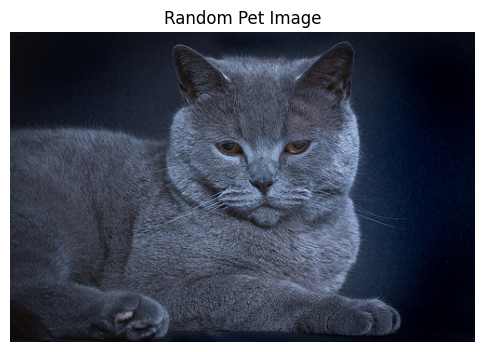

In [24]:
# Select a random pet image

import random
import os
from PIL import Image

random_image = random.choice(img)

image_path = os.path.join(path1, random_image)

original_image = Image.open(image_path).convert("RGB")

print("Selected image:", random_image)

plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title("Random Pet Image")
plt.axis("off")
plt.show()

In [25]:
# Resize and normalize the image exactly as done during training

input_image = original_image.resize((128, 128))

input_array = np.array(input_image, dtype=np.float32)

# Same normalization used in PreprocessData()
input_array = input_array / 256.0

# Add batch dimension
input_array = np.expand_dims(input_array, axis=0)

print("Input shape:", input_array.shape)

Input shape: (1, 128, 128, 3)


In [26]:
# Predict segmentation mask

prediction = loaded_model.predict(input_array)

# Convert model output to class labels
predicted_mask = tf.argmax(prediction[0], axis=-1)

predicted_mask = predicted_mask.numpy()

print("Predicted mask shape:", predicted_mask.shape)
print("Predicted classes:", np.unique(predicted_mask))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted mask shape: (128, 128)
Predicted classes: [0 1 2]


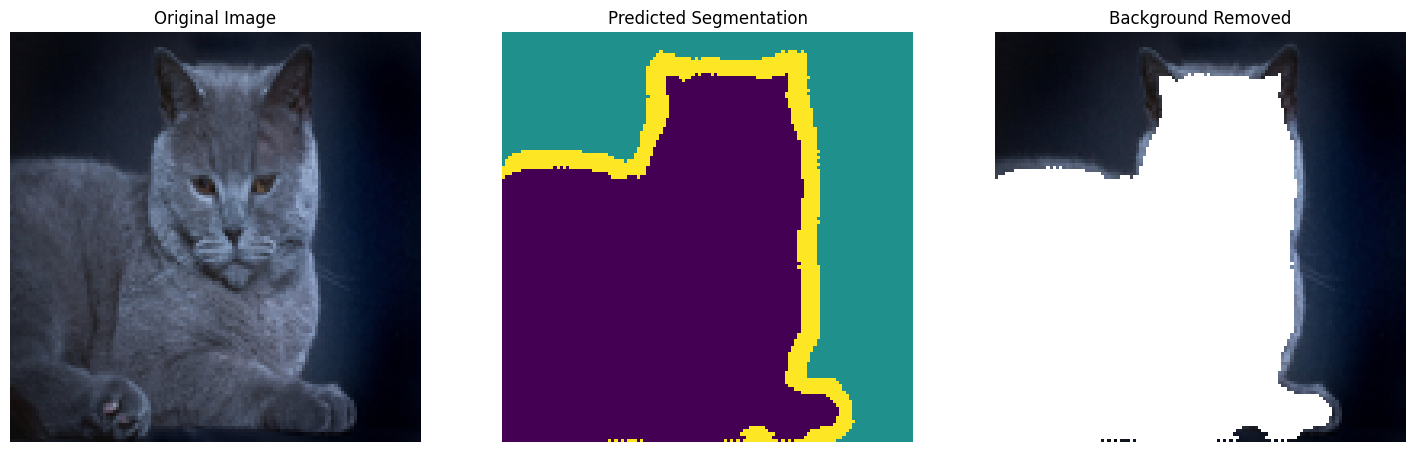

In [28]:
# Create foreground mask
# 0 = background, 1 = pet, 2 = outline

pet_mask = predicted_mask != 0

# Convert image to RGBA
image_rgba = np.array(input_image.convert("RGBA"))

# Make background transparent
image_rgba[~pet_mask, 3] = 0

# Display results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(input_image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(predicted_mask)
ax[1].set_title("Predicted Segmentation")
ax[1].axis("off")

ax[2].imshow(image_rgba)
ax[2].set_title("Background Removed")
ax[2].axis("off")

plt.show()

In [29]:
# Save the final image with transparent background

output_image = Image.fromarray(image_rgba)

output_image.save("pet_background_removed.png")

print("Background removed image saved successfully.")

Background removed image saved successfully.
